# 07 — Depuración de Variables para Modelo Predictivo

**Objetivo**: A partir del dataset integrado `contratos_adiciones_obra.parquet`,
construir tres variables binarias objetivo (**Alcance**, **Presupuesto**, **Tiempo**),
analizar correlaciones entre variables, e identificar columnas eliminables para el
modelo predictivo.

**Fuente**: `contratos_adiciones_obra.parquet` (48,331 contratos × 111 columnas)

**Convención binaria**: `0` = hubo modificación/adición, `1` = sin modificación.

---

## 1. Configuración y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = '../data/'
print('Configuración lista.')

Configuración lista.


In [2]:
df = pd.read_parquet(DATA_DIR + 'contratos_adiciones_obra.parquet')
df_adiciones = pd.read_parquet(DATA_DIR + 'adiciones_obra.parquet')

print(f'Contratos integrados: {df.shape}')
print(f'Adiciones crudas: {df_adiciones.shape}')

Contratos integrados: (48331, 111)
Adiciones crudas: (249037, 5)


## 2. Construcción de variables binarias objetivo

### Estrategia de derivación

| Variable | Señal principal | Señal complementaria (texto en adiciones) |
|---|---|---|
| **Tiempo** | `dias_adicionados > 0` (campo directo de SECOP) | tipo `EXTENSION` + texto con "prórroga", "amplia plazo" |
| **Presupuesto** | tipo `ADICION EN EL VALOR` | texto con "adición en valor", "adición presupuestal" |
| **Alcance** | — | texto con "modifica objeto", "alcance", "actividades nuevas" |

**Convención**: `0` = hubo modificación, `1` = sin modificación.

In [3]:
# ============================================================
# 2.1 Derivar flags a nivel adición individual
# ============================================================

# --- ALCANCE: Modificaciones al objeto/alcance del contrato ---
# Se infiere por NLP básico sobre la descripción de la adición.
# No existe un tipo explícito en SECOP para "cambio de alcance".
pat_alcance = r'(?i)(modifica.*objeto|modifica.*alcance|alcance|actividades?\s*nueva|incluir\s*actividad|cambio.*objeto|nuevo.*objeto|cambio.*alcance)'
df_adiciones['flag_alcance'] = (
    df_adiciones['descripcion'].str.contains(pat_alcance, na=False, regex=True)
).astype(int)

# --- PRESUPUESTO: Adiciones en dinero al contrato ---
# Señal 1: tipo explícito "ADICION EN EL VALOR"
# Señal 2: texto en MODIFICACION GENERAL que menciona adición en valor
pat_presupuesto = r'(?i)(adici[oó]n.*valor|adici[oó]n.*presupuest|valor.*adicion|incremento.*valor|adici[oó]n.*contrato.*\$)'
df_adiciones['flag_presupuesto'] = (
    (df_adiciones['tipo'] == 'ADICION EN EL VALOR') |
    df_adiciones['descripcion'].str.contains(pat_presupuesto, na=False, regex=True)
).astype(int)

# --- TIEMPO: Extensiones de plazo ---
# Señal 1: tipo explícito "EXTENSION"
# Señal 2: texto con prórroga/ampliación de plazo
pat_tiempo = r'(?i)(pr[oó]rroga|amplia.*plazo|extensi[oó]n.*plazo|plazo.*ejecuci[oó]n|ampliaci[oó]n.*tiempo|ampliar.*plazo|ampliaci[oó]n.*plazo)'
df_adiciones['flag_tiempo'] = (
    (df_adiciones['tipo'] == 'EXTENSION') |
    df_adiciones['descripcion'].str.contains(pat_tiempo, na=False, regex=True)
).astype(int)

print('Flags por adición individual:')
print(f'  Alcance:      {df_adiciones["flag_alcance"].sum():,} adiciones')
print(f'  Presupuesto:  {df_adiciones["flag_presupuesto"].sum():,} adiciones')
print(f'  Tiempo:       {df_adiciones["flag_tiempo"].sum():,} adiciones')

Flags por adición individual:
  Alcance:      4,373 adiciones
  Presupuesto:  16,718 adiciones
  Tiempo:       66,433 adiciones


In [4]:
# ============================================================
# 2.2 Agregar a nivel contrato (al menos 1 adición con flag)
# ============================================================
agg_flags = df_adiciones.groupby('id_contrato').agg(
    _alcance_ad=('flag_alcance', 'max'),
    _presupuesto_ad=('flag_presupuesto', 'max'),
    _tiempo_ad=('flag_tiempo', 'max')
).reset_index()

# Merge con el dataset integrado
df = df.merge(agg_flags, on='id_contrato', how='left')

# Contratos sin adiciones -> no tuvieron modificación -> llenar con 0
for col in ['_alcance_ad', '_presupuesto_ad', '_tiempo_ad']:
    df[col] = df[col].fillna(0).astype(int)

print(f'Contratos con flag alcance (desde adiciones):      {df["_alcance_ad"].sum():,}')
print(f'Contratos con flag presupuesto (desde adiciones):  {df["_presupuesto_ad"].sum():,}')
print(f'Contratos con flag tiempo (desde adiciones):       {df["_tiempo_ad"].sum():,}')

Contratos con flag alcance (desde adiciones):      1,697
Contratos con flag presupuesto (desde adiciones):  8,020
Contratos con flag tiempo (desde adiciones):       16,802


In [5]:
# ============================================================
# 2.3 Construir las 3 columnas binarias finales
# ============================================================

# ALCANCE: 0 si hubo cambio de alcance, 1 si no.
# Fuente: texto en adiciones.
df['alcance'] = (~df['_alcance_ad'].astype(bool)).astype(int)

# PRESUPUESTO: 0 si hubo adición presupuestal, 1 si no.
# Fuente: tipo ADICION EN EL VALOR  +  texto en MODIFICACION GENERAL.
df['presupuesto'] = (~df['_presupuesto_ad'].astype(bool)).astype(int)

# TIEMPO: 0 si hubo extensión de tiempo, 1 si no.
# Fuente principal: dias_adicionados > 0 (campo directo SECOP).
# Fuente complementaria: texto en adiciones.
df['tiempo'] = (~((df['dias_adicionados'] > 0) | (df['_tiempo_ad'].astype(bool)))).astype(int)

# Eliminar columnas auxiliares
df.drop(columns=['_alcance_ad', '_presupuesto_ad', '_tiempo_ad'], inplace=True)

print('=== Variables binarias objetivo ===')
print(f'Alcance     — sin cambio (1): {df["alcance"].sum():>6,} ({df["alcance"].mean()*100:.1f}%)  |  con cambio (0): {(df["alcance"]==0).sum():>6,} ({(df["alcance"]==0).mean()*100:.1f}%)')
print(f'Presupuesto — sin adición (1): {df["presupuesto"].sum():>6,} ({df["presupuesto"].mean()*100:.1f}%)  |  con adición (0): {(df["presupuesto"]==0).sum():>6,} ({(df["presupuesto"]==0).mean()*100:.1f}%)')
print(f'Tiempo      — sin extensión (1): {df["tiempo"].sum():>6,} ({df["tiempo"].mean()*100:.1f}%)  |  con extensión (0): {(df["tiempo"]==0).sum():>6,} ({(df["tiempo"]==0).mean()*100:.1f}%)')

=== Variables binarias objetivo ===
Alcance     — sin cambio (1): 46,634 (96.5%)  |  con cambio (0):  1,697 (3.5%)
Presupuesto — sin adición (1): 40,311 (83.4%)  |  con adición (0):  8,020 (16.6%)
Tiempo      — sin extensión (1): 29,232 (60.5%)  |  con extensión (0): 19,099 (39.5%)


In [6]:
# ============================================================
# 2.4 Validación cruzada de las 3 variables
# ============================================================
print('=== Tabla cruzada: Presupuesto vs Tiempo ===')
ct1 = pd.crosstab(df['presupuesto'], df['tiempo'], margins=True)
ct1.index = ['Con adición (0)', 'Sin adición (1)', 'Total']
ct1.columns = ['Con extensión (0)', 'Sin extensión (1)', 'Total']
print(ct1)

print('\n=== Tabla cruzada: Alcance vs Presupuesto ===')
ct2 = pd.crosstab(df['alcance'], df['presupuesto'], margins=True)
ct2.index = ['Con cambio alcance (0)', 'Sin cambio alcance (1)', 'Total']
ct2.columns = ['Con adición ppto (0)', 'Sin adición ppto (1)', 'Total']
print(ct2)

print('\n=== Tabla cruzada: Alcance vs Tiempo ===')
ct3 = pd.crosstab(df['alcance'], df['tiempo'], margins=True)
ct3.index = ['Con cambio alcance (0)', 'Sin cambio alcance (1)', 'Total']
ct3.columns = ['Con extensión (0)', 'Sin extensión (1)', 'Total']
print(ct3)

=== Tabla cruzada: Presupuesto vs Tiempo ===
                 Con extensión (0)  Sin extensión (1)  Total
Con adición (0)               5283               2737   8020
Sin adición (1)              13816              26495  40311
Total                        19099              29232  48331

=== Tabla cruzada: Alcance vs Presupuesto ===
                        Con adición ppto (0)  Sin adición ppto (1)  Total
Con cambio alcance (0)                   757                   940   1697
Sin cambio alcance (1)                  7263                 39371  46634
Total                                   8020                 40311  48331

=== Tabla cruzada: Alcance vs Tiempo ===
                        Con extensión (0)  Sin extensión (1)  Total
Con cambio alcance (0)               1380                317   1697
Sin cambio alcance (1)              17719              28915  46634
Total                               19099              29232  48331


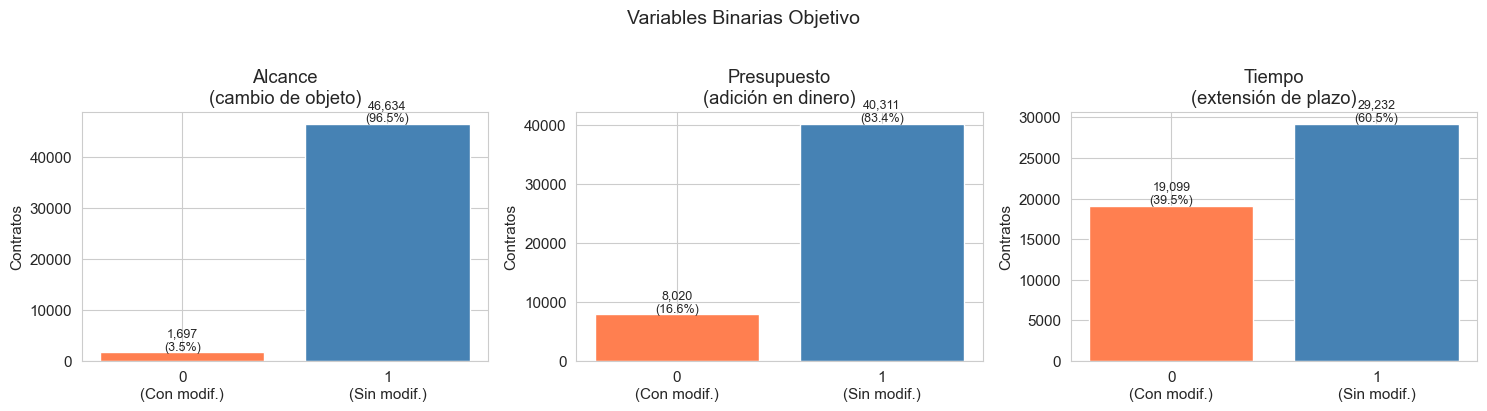

In [7]:
# Visualización de las 3 variables target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, titulo in zip(axes,
    ['alcance', 'presupuesto', 'tiempo'],
    ['Alcance\n(cambio de objeto)', 'Presupuesto\n(adición en dinero)', 'Tiempo\n(extensión de plazo)']):
    counts = df[col].value_counts().sort_index()
    colors = ['coral', 'steelblue']
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0\n(Con modif.)', '1\n(Sin modif.)'])
    ax.set_title(titulo)
    ax.set_ylabel('Contratos')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 300,
                f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.suptitle('Variables Binarias Objetivo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Análisis de correlación

Evaluamos la correlación entre **todas** las variables numéricas del dataset
integrado para identificar redundancias que comprometerían el modelo predictivo.

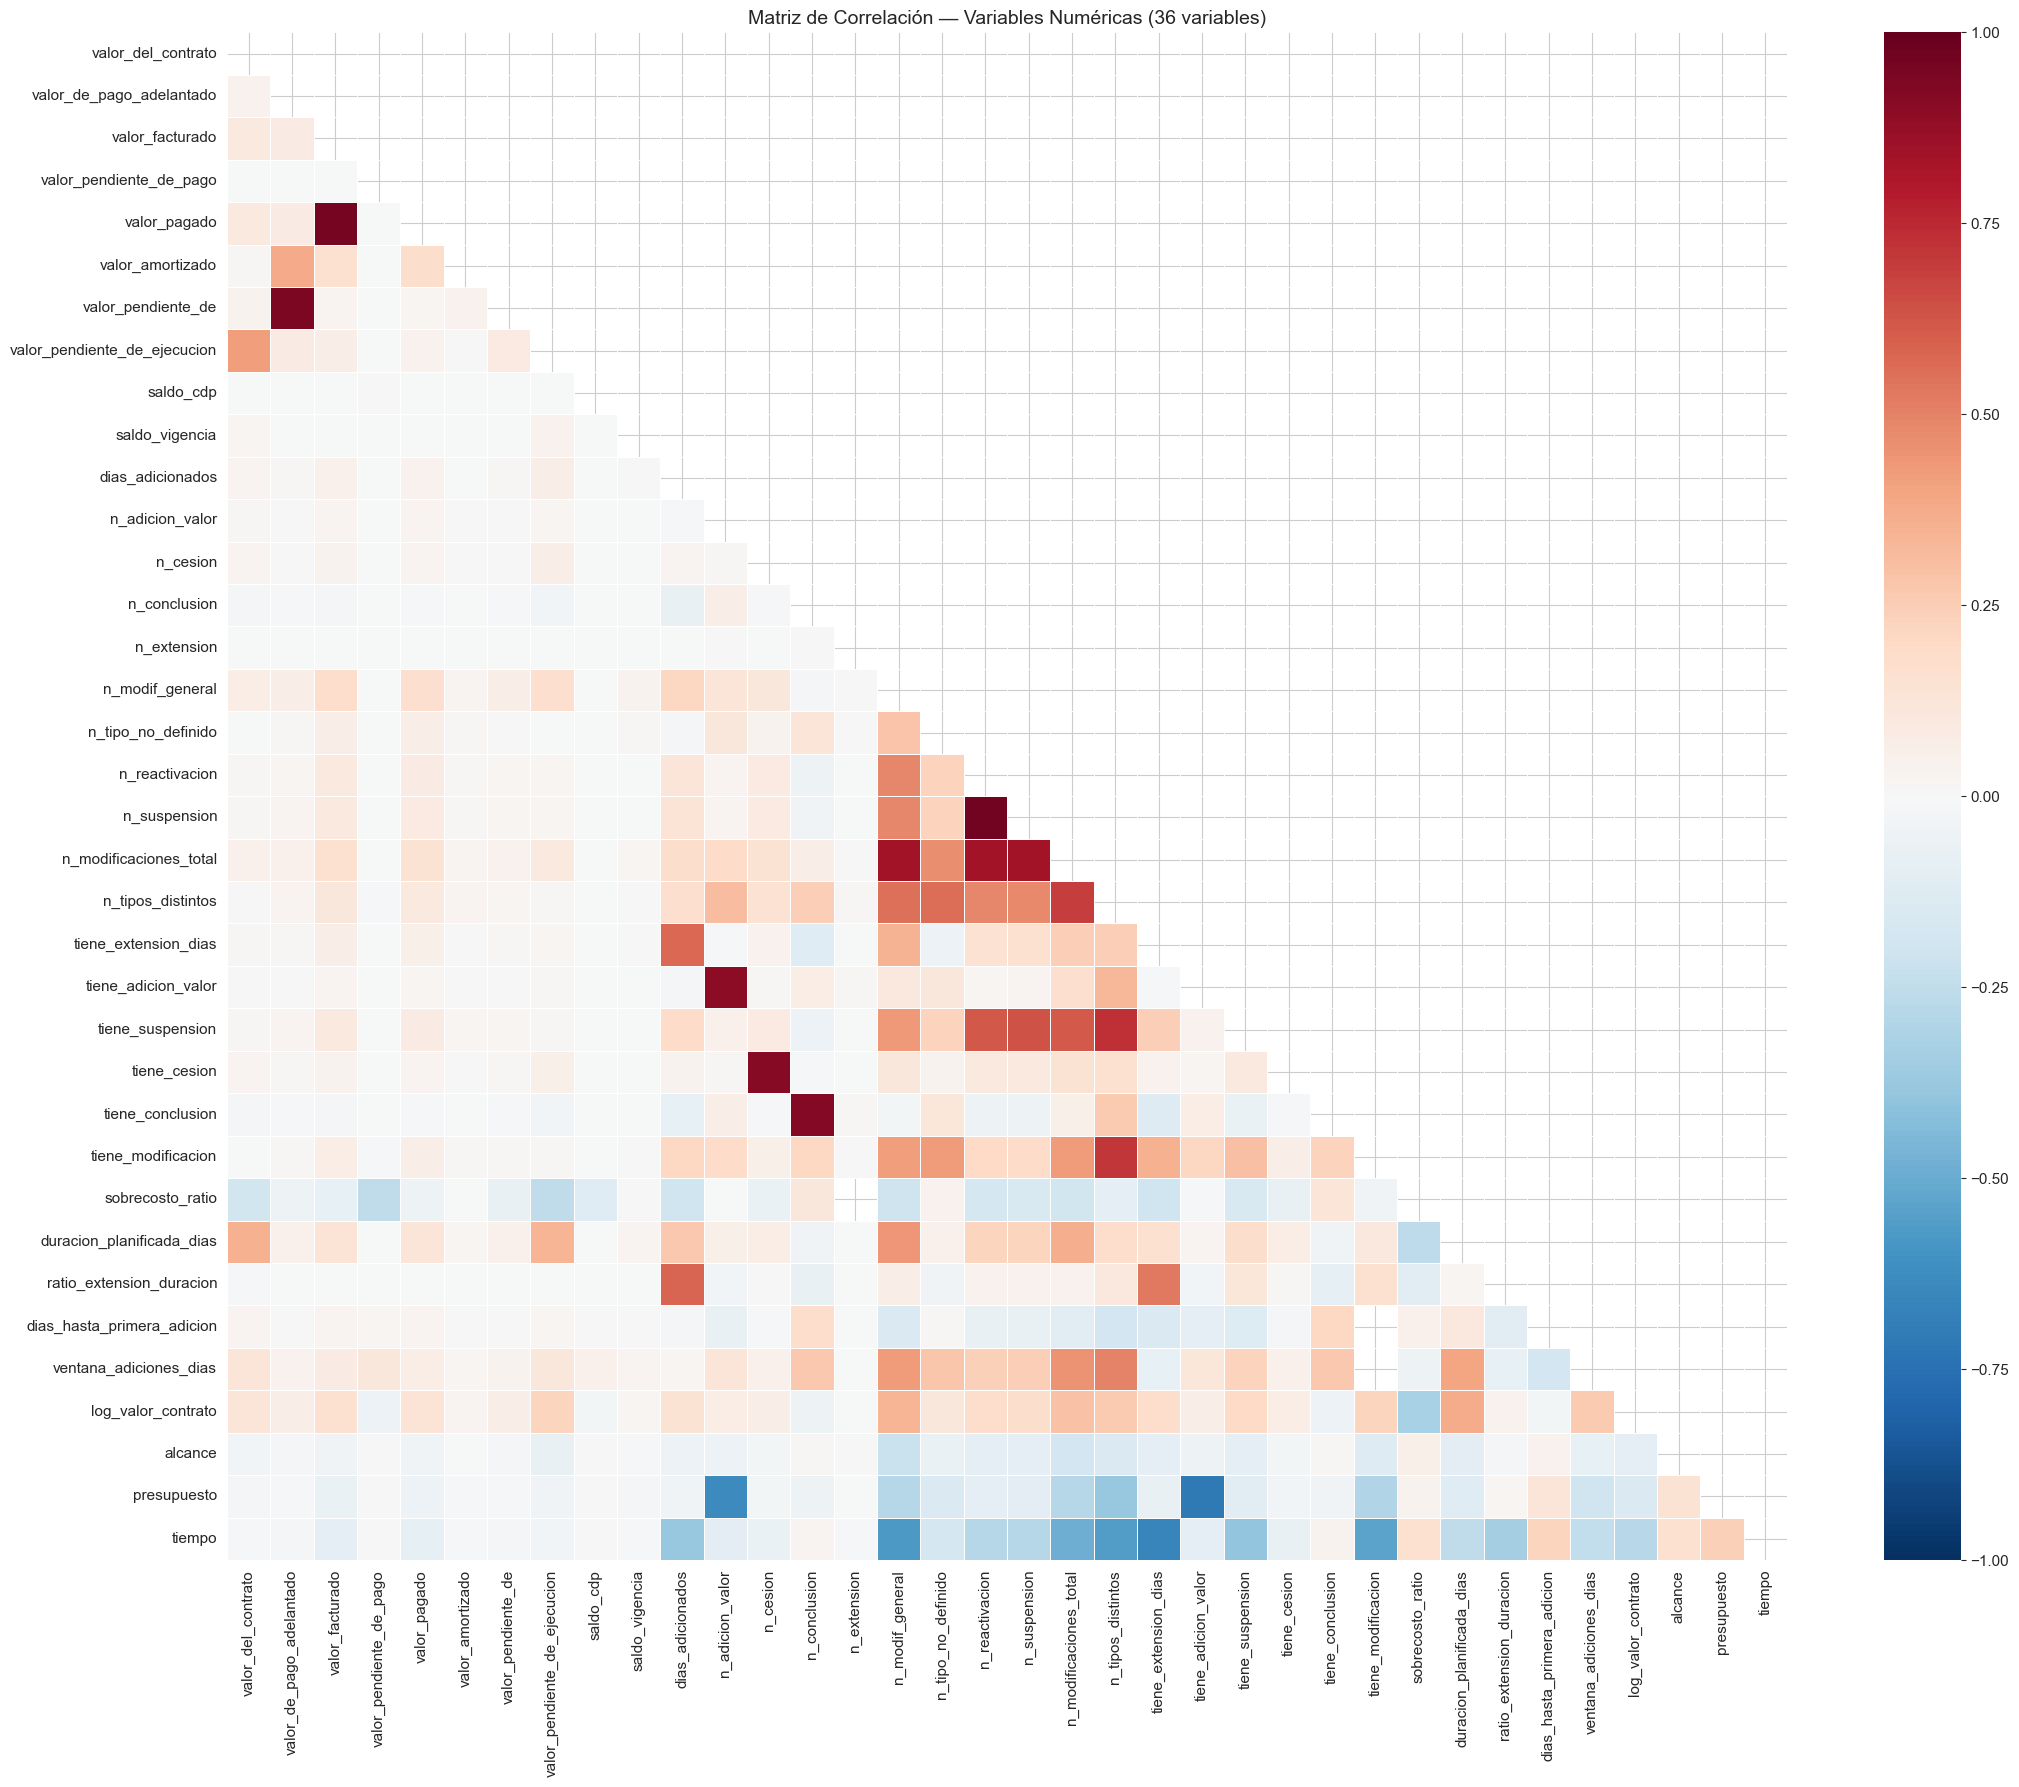

In [8]:
# ============================================================
# 3.1 Matriz de correlación completa
# ============================================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación — Variables Numéricas (36 variables)', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 3.2 Pares con alta correlación (|r| > 0.7)
# ============================================================
pares_alta = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pares_alta.append({
                'variable_1': num_cols[i],
                'variable_2': num_cols[j],
                'r': round(r, 4)
            })

df_pares = pd.DataFrame(pares_alta).sort_values('r', ascending=False, key=abs)
print(f'Pares con |r| > 0.7: {len(df_pares)}')
df_pares

Pares con |r| > 0.7: 12


,variable_1,variable_2,r
6,n_reactivacion,n_suspension,0.9660
1,valor_facturado,valor_pagado,0.9546
0,valor_de_pago_adelantado,valor_pendiente_de,0.9410
4,n_conclusion,tiene_conclusion,0.9172
3,n_cesion,tiene_cesion,0.9081
2,n_adicion_valor,tiene_adicion_valor,0.8938
5,n_modif_general,n_modificaciones_total,0.8433
8,n_suspension,n_modificaciones_total,0.8382
7,n_reactivacion,n_modificaciones_total,0.8371
9,n_tipos_distintos,tiene_suspension,0.7321


In [10]:
# ============================================================
# 3.3 Pares con correlación moderada (0.5 < |r| ≤ 0.7)
# ============================================================
pares_mod = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r = corr.iloc[i, j]
        if 0.5 < abs(r) <= 0.7:
            pares_mod.append({
                'variable_1': num_cols[i],
                'variable_2': num_cols[j],
                'r': round(r, 4)
            })

df_pares_mod = pd.DataFrame(pares_mod).sort_values('r', ascending=False, key=abs)
print(f'Pares con 0.5 < |r| ≤ 0.7: {len(df_pares_mod)}')
df_pares_mod

Pares con 0.5 < |r| ≤ 0.7: 14


,variable_1,variable_2,r
8,n_modificaciones_total,n_tipos_distintos,0.6939
12,tiene_extension_dias,tiempo,-0.6597
2,n_adicion_valor,presupuesto,-0.6393
7,n_suspension,tiene_suspension,0.6368
6,n_reactivacion,tiene_suspension,0.6209
9,n_modificaciones_total,tiene_suspension,0.6125
1,dias_adicionados,ratio_extension_duracion,0.5846
4,n_modif_general,tiempo,-0.5730
0,dias_adicionados,tiene_extension_dias,0.5728
5,n_tipo_no_definido,n_tipos_distintos,0.5556


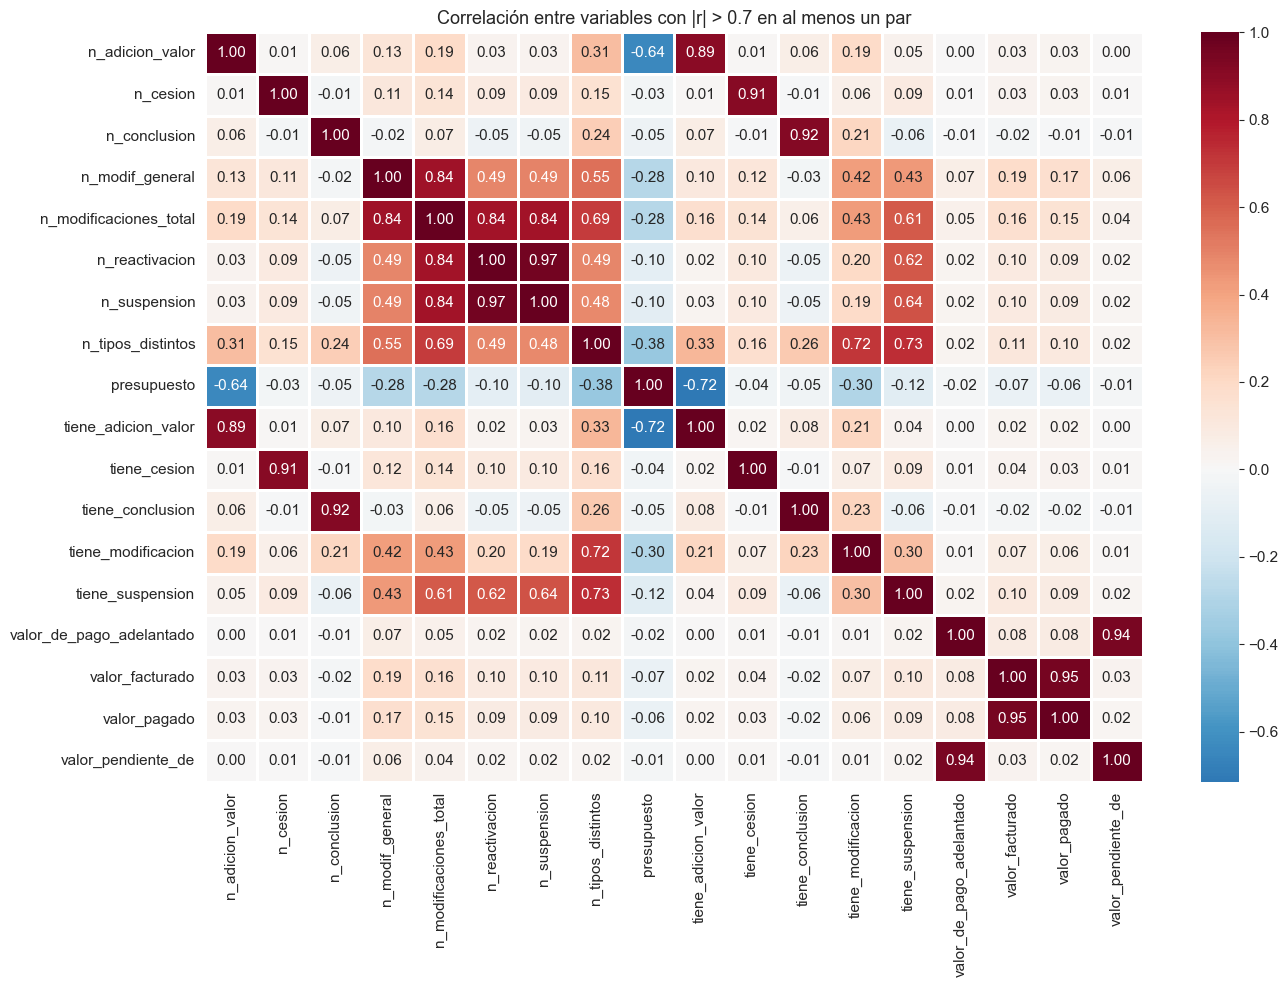

In [11]:
# ============================================================
# 3.4 Heatmap focalizado: solo pares correlacionados
# ============================================================
# Seleccionar variables involucradas en correlaciones altas
vars_corr = set()
for _, row in df_pares.iterrows():
    vars_corr.add(row['variable_1'])
    vars_corr.add(row['variable_2'])
vars_corr = sorted(vars_corr)

corr_subset = df[vars_corr].corr()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=1)
ax.set_title('Correlación entre variables con |r| > 0.7 en al menos un par', fontsize=13)
plt.tight_layout()
plt.show()

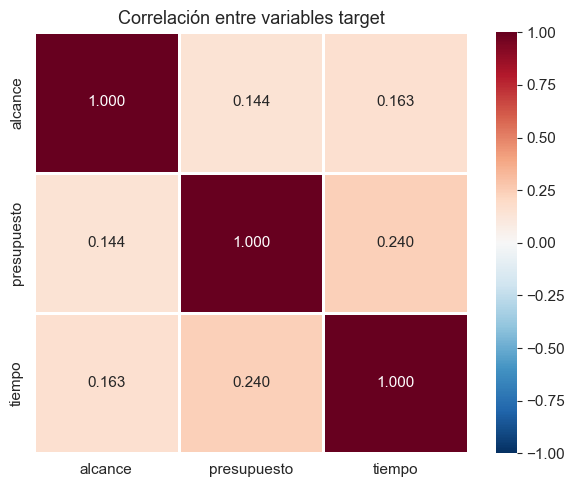

Correlaciones entre targets:
  alcance <-> presupuesto: r = 0.1436
  alcance <-> tiempo: r = 0.1631
  presupuesto <-> tiempo: r = 0.2405


In [12]:
# ============================================================
# 3.5 Correlación de las 3 nuevas variables target entre sí
# ============================================================
targets = ['alcance', 'presupuesto', 'tiempo']
corr_targets = df[targets].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_targets, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=1, vmin=-1, vmax=1)
ax.set_title('Correlación entre variables target', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlaciones entre targets:')
for i in range(len(targets)):
    for j in range(i+1, len(targets)):
        r = corr_targets.iloc[i, j]
        print(f'  {targets[i]} <-> {targets[j]}: r = {r:.4f}')

## 4. Identificación de columnas a eliminar

Clasificamos las columnas en categorías de eliminación según criterios de
modelado predictivo.

In [13]:
# ============================================================
# 4.1 Categoría A: Identificadores y texto libre (no predictivos)
# ============================================================
cat_a_ids = [
    'id_contrato',               # PK
    'proceso_de_compra',         # ID de proceso
    'referencia_del_contrato',   # ID generado por entidad
    'nit_entidad',               # ID fiscal (alta cardinalidad)
    'codigo_entidad',            # ID plataforma
    'codigo_proveedor',          # ID proveedor
    'documento_proveedor',       # Documento proveedor
    'c_digo_bpin',               # Código proyecto inversión
    'n_mero_de_cuenta',          # Número de cuenta bancaria
    'identificaci_n_representante_legal',  # Doc representante
    'n_mero_de_documento_ordenador_del_gasto',
    'n_mero_de_documento_supervisor',
    'n_mero_de_documento_ordenador_de_pago',
    'codigo_de_categoria_principal',  # UNSPSC (usable si se agrupa, pero como texto no)
]

cat_a_texto = [
    'descripcion_del_proceso',   # Texto libre
    'objeto_del_contrato',       # Texto libre
    'urlproceso',                # URL
    'proveedor_adjudicado',      # Nombre proveedor (alta cardinalidad)
    'nombre_entidad',            # Nombre entidad (alta cardinalidad)
    'nombre_representante_legal',
    'domicilio_representante_legal',
    'nombre_ordenador_del_gasto',
    'nombre_supervisor',
    'nombre_ordenador_de_pago',
    'nombre_del_banco',
    'localizaci_n',              # Redundante con departamento + ciudad
    'duraci_n_del_contrato',     # Texto "X meses" (ya capturada en duracion_planificada_dias)
]

cat_a = cat_a_ids + cat_a_texto
print(f'Categoría A (IDs + texto libre): {len(cat_a)} columnas')
for c in cat_a:
    exists = c in df.columns
    nunique = df[c].nunique() if exists else 'N/A'
    print(f'  {"✓" if exists else "✗"} {c} — {nunique} únicos')

Categoría A (IDs + texto libre): 27 columnas
  ✓ id_contrato — 48331 únicos
  ✓ proceso_de_compra — 43451 únicos
  ✓ referencia_del_contrato — 45910 únicos
  ✓ nit_entidad — 2270 únicos
  ✓ codigo_entidad — 2534 únicos
  ✓ codigo_proveedor — 23192 únicos
  ✓ documento_proveedor — 18641 únicos
  ✓ c_digo_bpin — 7771 únicos
  ✓ n_mero_de_cuenta — 5574 únicos
  ✓ identificaci_n_representante_legal — 5809 únicos
  ✓ n_mero_de_documento_ordenador_del_gasto — 4422 únicos
  ✓ n_mero_de_documento_supervisor — 5911 únicos
  ✓ n_mero_de_documento_ordenador_de_pago — 907 únicos
  ✓ codigo_de_categoria_principal — 1506 únicos
  ✓ descripcion_del_proceso — 43445 únicos
  ✓ objeto_del_contrato — 43572 únicos
  ✓ urlproceso — 43449 únicos
  ✓ proveedor_adjudicado — 22770 únicos
  ✓ nombre_entidad — 2528 únicos
  ✓ nombre_representante_legal — 15760 únicos
  ✓ domicilio_representante_legal — 4511 únicos
  ✓ nombre_ordenador_del_gasto — 4487 únicos
  ✓ nombre_supervisor — 6084 únicos
  ✓ nombre_ordenad

In [14]:
# ============================================================
# 4.2 Categoría B: Data leakage (información post-resultado)
# ============================================================
cat_b = [
    'valor_facturado',              # Se conoce después de la ejecución
    'valor_pagado',                 # Se conoce después de la ejecución
    'valor_pendiente_de_pago',      # Derivado de la ejecución
    'valor_pendiente_de_ejecucion', # Derivado de la ejecución
    'valor_amortizado',             # Se conoce durante/post ejecución
    'valor_pendiente_de',           # Pendiente de amortización
    'saldo_cdp',                    # Estado presupuestal actualizado
    'saldo_vigencia',               # Estado presupuestal actualizado
    'sobrecosto_ratio',             # Calculado con valor_pagado (leakage)
    'liquidaci_n',                  # Estado post-ejecución
    'estado_contrato',              # Estado actual (incluye "Modificado", "terminado")
    'ultima_actualizacion',         # Fecha de actualización post-hoc
    'fecha_inicio_liquidacion',     # Post-ejecución
    'fecha_fin_liquidacion',        # Post-ejecución
    'fecha_de_notificaci_n_de_prorrogaci_n',  # Solo existe si hubo prórroga (leakage directo)
]

print(f'Categoría B (data leakage): {len(cat_b)} columnas')
for c in cat_b:
    exists = c in df.columns
    print(f'  {"✓" if exists else "✗"} {c}')

Categoría B (data leakage): 15 columnas
  ✓ valor_facturado
  ✓ valor_pagado
  ✓ valor_pendiente_de_pago
  ✓ valor_pendiente_de_ejecucion
  ✓ valor_amortizado
  ✓ valor_pendiente_de
  ✓ saldo_cdp
  ✓ saldo_vigencia
  ✓ sobrecosto_ratio
  ✓ liquidaci_n
  ✓ estado_contrato
  ✓ ultima_actualizacion
  ✓ fecha_inicio_liquidacion
  ✓ fecha_fin_liquidacion
  ✓ fecha_de_notificaci_n_de_prorrogaci_n


In [15]:
# ============================================================
# 4.3 Categoría C: Varianza cero o casi-cero
# ============================================================
cat_c = []
print('Variables con varianza muy baja:')
for c in df.columns:
    n_unique = df[c].nunique()
    if n_unique == 1:
        cat_c.append(c)
        print(f'  {c}: {n_unique} valor único → "{df[c].iloc[0]}"')
    elif n_unique == 2 and df[c].dtype in ['object', 'str', 'string']:
        # Verificar si una categoría domina con >99%
        top_pct = df[c].value_counts(normalize=True).iloc[0] * 100
        if top_pct > 99:
            cat_c.append(c)
            print(f'  {c}: top={top_pct:.1f}% → casi constante')

# n_extension tiene solo 2 contratos con >0
if 'n_extension' in df.columns:
    n_ext_gt0 = (df['n_extension'] > 0).sum()
    if n_ext_gt0 <= 10:
        cat_c.append('n_extension')
        print(f'  n_extension: solo {n_ext_gt0} contratos con >0 → prácticamente constante')

print(f'\nCategoría C (varianza ~cero): {len(cat_c)} columnas')

Variables con varianza muy baja:
  tipo_de_contrato: 1 valor único → "Obra"
  obligaciones_postconsumo: top=99.8% → casi constante
  reversion: top=100.0% → casi constante
  espostconflicto: top=99.7% → casi constante
  n_extension: solo 2 contratos con >0 → prácticamente constante

Categoría C (varianza ~cero): 5 columnas


In [16]:
# ============================================================
# 4.4 Categoría D: Redundancia por alta correlación (|r| > 0.7)
# ============================================================
# Decisión de cuál eliminar en cada par:

cat_d = [
    'valor_pendiente_de',       # r=0.94 con valor_de_pago_adelantado → mantener valor_de_pago_adelantado
    'valor_pagado',             # r=0.95 con valor_facturado (ambos son leakage, ya en cat_b)
    'n_adicion_valor',          # r=0.89 con tiene_adicion_valor → mantener la binaria
    'n_cesion',                 # r=0.91 con tiene_cesion → mantener la binaria
    'n_conclusion',             # r=0.92 con tiene_conclusion → mantener la binaria
    'n_reactivacion',           # r=0.97 con n_suspension → mantener n_suspension (más interpretable)
    'n_modificaciones_total',   # r>0.83 con n_modif_general, n_reactivacion, n_suspension
    'log_valor_contrato',       # Derivada de valor_del_contrato (siempre recalculable)
]

# Agregar la redundancia con las nuevas variables
# tiene_adicion_valor es redundante con presupuesto (invertida)
# tiene_extension_dias es redundante con tiempo (invertida + complemento de texto)
cat_d.extend([
    'tiene_adicion_valor',      # Capturada por 'presupuesto' (con más cobertura)
    'tiene_extension_dias',     # Capturada por 'tiempo' (con más cobertura)
    'tiene_modificacion',       # Genérica: capturada por alcance + presupuesto + tiempo
])

print(f'Categoría D (redundancia por correlación): {len(cat_d)} columnas')
for c in cat_d:
    print(f'  {c}')

Categoría D (redundancia por correlación): 11 columnas
  valor_pendiente_de
  valor_pagado
  n_adicion_valor
  n_cesion
  n_conclusion
  n_reactivacion
  n_modificaciones_total
  log_valor_contrato
  tiene_adicion_valor
  tiene_extension_dias
  tiene_modificacion


In [17]:
# ============================================================
# 4.5 Categoría E: Redundantes por semántica (no por correlación numérica)
# ============================================================
cat_e = [
    'tipo_de_identificaci_n_representante_legal',  # Tipo doc → ya no predictivo
    'tipo_de_documento_ordenador_del_gasto',       # Tipo doc no aporta
    'tipo_de_documento_supervisor',                # Tipo doc no aporta
    'tipo_de_documento_ordenador_de_pago',         # Tipo doc no aporta (95% "No definido")
    'tipodocproveedor',                            # Tipo doc proveedor (redundante con es_grupo/es_pyme)
    'nacionalidad_representante_legal',            # 97% colombiana
    'puntos_del_acuerdo',         # 99.8% "No aplica" → redundante con espostconflicto
    'pilares_del_acuerdo',        # 99.8% "No aplica" → redundante con espostconflicto
    'anno_bpin',                  # Redundante con estado_bpin
    'descripcion_documentos_tipo', # Redundante con documentos_tipo
    'justificacion_modalidad_de',  # Altamente correlacionada con modalidad_de_contratacion
]

print(f'Categoría E (redundancia semántica): {len(cat_e)} columnas')
for c in cat_e:
    if c in df.columns:
        n_unique = df[c].nunique()
        top_val = df[c].value_counts().iloc[0]
        top_pct = top_val / len(df) * 100
        print(f'  {c}: {n_unique} únicos, top={top_pct:.1f}%')

Categoría E (redundancia semántica): 11 columnas
  tipo_de_identificaci_n_representante_legal: 7 únicos, top=61.3%
  tipo_de_documento_ordenador_del_gasto: 8 únicos, top=63.8%
  tipo_de_documento_supervisor: 7 únicos, top=54.3%
  tipo_de_documento_ordenador_de_pago: 7 únicos, top=94.9%
  tipodocproveedor: 7 únicos, top=76.5%
  nacionalidad_representante_legal: 9 únicos, top=97.3%
  puntos_del_acuerdo: 5 únicos, top=99.7%
  pilares_del_acuerdo: 14 únicos, top=99.7%
  anno_bpin: 8 únicos, top=59.5%
  descripcion_documentos_tipo: 9 únicos, top=80.4%
  justificacion_modalidad_de: 21 únicos, top=25.9%


In [18]:
# ============================================================
# 4.6 Categoría F: Fechas en bruto (no usables directamente)
# ============================================================
cat_f = [
    'fecha_de_firma',
    'fecha_de_inicio_del_contrato',
    'fecha_de_fin_del_contrato',
    'fecha_primera_adicion',
    'fecha_ultima_adicion',
]
# Nota: estas fechas ya se usaron para derivar duracion_planificada_dias,
# dias_hasta_primera_adicion, ventana_adiciones_dias.
# Las fechas en bruto NO entran a un modelo tabular directamente.

print(f'Categoría F (fechas en bruto): {len(cat_f)} columnas')
print('Estas columnas ya fueron transformadas en features numéricos derivados.')
for c in cat_f:
    if c in df.columns:
        null_pct = df[c].isnull().mean() * 100
        print(f'  {c}: {null_pct:.1f}% nulos')

Categoría F (fechas en bruto): 5 columnas
Estas columnas ya fueron transformadas en features numéricos derivados.
  fecha_de_firma: 10.7% nulos
  fecha_de_inicio_del_contrato: 12.6% nulos
  fecha_de_fin_del_contrato: 3.1% nulos
  fecha_primera_adicion: 30.8% nulos
  fecha_ultima_adicion: 30.8% nulos


In [19]:
# ============================================================
# 4.7 Resumen de eliminación
# ============================================================
todas_eliminar = set(cat_a + cat_b + cat_c + cat_d + cat_e + cat_f)
# Verificar que todas existen en el dataset
existentes = [c for c in todas_eliminar if c in df.columns]
no_existen = [c for c in todas_eliminar if c not in df.columns]

print(f'Total columnas a eliminar: {len(existentes)} / {len(df.columns)}')
print(f'Columnas que se conservan: {len(df.columns) - len(existentes)}')
if no_existen:
    print(f'\nAdvertencia — no encontradas en df: {no_existen}')

print(f'\n{"="*60}')
print(f'{"RESUMEN POR CATEGORÍA":^60}')
print(f'{"="*60}')
for nombre, cols in [('A: IDs/Texto libre', cat_a),
                      ('B: Data leakage', cat_b),
                      ('C: Varianza ~cero', cat_c),
                      ('D: Redundancia corr.', cat_d),
                      ('E: Redundancia semánt.', cat_e),
                      ('F: Fechas en bruto', cat_f)]:
    n = len([c for c in cols if c in df.columns])
    print(f'  {nombre:.<40} {n:>3} columnas')

# Columnas conservadas
conservadas = [c for c in df.columns if c not in todas_eliminar]
print(f'\n{"="*60}')
print(f'COLUMNAS CONSERVADAS ({len(conservadas)}):')
print(f'{"="*60}')
for c in conservadas:
    dtype = df[c].dtype
    null_pct = df[c].isnull().mean() * 100
    print(f'  {c:<55} {str(dtype):<15} nulos={null_pct:.1f}%')

Total columnas a eliminar: 72 / 114
Columnas que se conservan: 42

                   RESUMEN POR CATEGORÍA                    
  A: IDs/Texto libre......................  27 columnas
  B: Data leakage.........................  15 columnas
  C: Varianza ~cero.......................   5 columnas
  D: Redundancia corr.....................  11 columnas
  E: Redundancia semánt...................  11 columnas
  F: Fechas en bruto......................   5 columnas

COLUMNAS CONSERVADAS (42):
  departamento                                            str             nulos=0.0%
  ciudad                                                  str             nulos=0.0%
  orden                                                   str             nulos=0.0%
  sector                                                  str             nulos=0.0%
  rama                                                    str             nulos=0.0%
  entidad_centralizada                                    str             nulos=0.0

## 5. Dataset depurado

In [20]:
# ============================================================
# 5.1 Guardar dataset con las 3 nuevas columnas (antes de eliminar)
# ============================================================
import os

# Guardar versión completa con las 3 nuevas columnas
output_full = DATA_DIR + 'contratos_adiciones_obra.parquet'
df.to_parquet(output_full, index=False)
size_mb = os.path.getsize(output_full) / (1024 * 1024)
print(f'Guardado (completo): {output_full}')
print(f'  Registros: {len(df):,} — Columnas: {len(df.columns)} — Tamaño: {size_mb:.1f} MB')

# Guardar versión depurada (sin columnas eliminadas)
df_depurado = df.drop(columns=[c for c in todas_eliminar if c in df.columns])
output_dep = DATA_DIR + 'contratos_depurado_modelo.parquet'
df_depurado.to_parquet(output_dep, index=False)
size_mb_dep = os.path.getsize(output_dep) / (1024 * 1024)
print(f'\nGuardado (depurado): {output_dep}')
print(f'  Registros: {len(df_depurado):,} — Columnas: {len(df_depurado.columns)} — Tamaño: {size_mb_dep:.1f} MB')

print(f'\nColumnas nuevas agregadas:')
for c in ['alcance', 'presupuesto', 'tiempo']:
    print(f'  - {c}')

print(f'\nColumnas en dataset depurado:')
for i, c in enumerate(df_depurado.columns):
    print(f'  {i+1:2d}. {c}')

Guardado (completo): ../data/contratos_adiciones_obra.parquet
  Registros: 48,331 — Columnas: 114 — Tamaño: 16.1 MB

Guardado (depurado): ../data/contratos_depurado_modelo.parquet
  Registros: 48,331 — Columnas: 42 — Tamaño: 1.5 MB

Columnas nuevas agregadas:
  - alcance
  - presupuesto
  - tiempo

Columnas en dataset depurado:
   1. departamento
   2. ciudad
   3. orden
   4. sector
   5. rama
   6. entidad_centralizada
   7. modalidad_de_contratacion
   8. condiciones_de_entrega
   9. es_grupo
  10. es_pyme
  11. habilita_pago_adelantado
  12. obligaci_n_ambiental
  13. origen_de_los_recursos
  14. destino_gasto
  15. valor_del_contrato
  16. valor_de_pago_adelantado
  17. estado_bpin
  18. dias_adicionados
  19. g_nero_representante_legal
  20. presupuesto_general_de_la_nacion_pgn
  21. sistema_general_de_participaciones
  22. sistema_general_de_regal_as
  23. recursos_propios_alcald_as_gobernaciones_y_resguardos_ind_genas_
  24. recursos_de_credito
  25. recursos_propios
  26. tipo